---
title: "Singular value spectrum of subspaces obtained from CVSR on PGC data"
author: "Saikat Banerjee"
format:
  html: default
date: "2026-06-02"
file-modified: "2026-06-02"
abstract: "This notebook analyzes the singular values from PGC data subspaces."
---

## Background

The projection distances between subspaces obtained from PGC data are very noisy for the NNM-Corr model.
Diagnostics revealed this could be due to the small spectral gap at the k / k+1 boundary.
[Click here to view the diagnostics notebook](./2026-06-02-cvsr-diagnostics-pgd-afw-nnm-corr.ipynb).
On the other hand, the NNM model shows a monotonically decreasing projection distance, as expected.
Here, we compare the singular values obtained from NNM and NNM-Corr models.

In [1]:
import re
import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils
mpl_stylesheet.banskt_presentation(splinecolor='black', dpi=300, colors='kelly')

from matplotlib import colormaps as mpl_cmaps
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
data_root = "/gpfs/commons/groups/knowles_lab/data/PsychGen/analysis/clorinn/cv_split_replication"
subspace_out_dir = Path(data_root) / "subspace"

In [3]:
def load_subspace_npz(subspace_dir, prefix):
    subspace_dir = Path(subspace_dir)
    rows = []
    for path in subspace_dir.glob(f"{prefix}_r*.npz"):
        with np.load(path, allow_pickle=False) as data:
            n_folds = int(data["n_folds"])
            nucnorm = data["nucnorm"].item()
            repeat_id = data["repeat_id"].item()
            for f in range(n_folds):
                s = data[f"s_f{f}"]
                n_factors = len(s)
                row = {
                    "nucnorm": nucnorm,
                    "repeat_id": repeat_id,
                    "fold_id": f,
                }
                row.update({f"s{k}": s[k] for k in range(n_factors)})
                rows.append(row)
    df = (pd.DataFrame(rows)
              .sort_values(["nucnorm","repeat_id", "fold_id"])
              .reset_index(drop=True))
    return df

def get_subspace_spectrum(subspace_df, use_mean=False, repeat_id=0, fold_id=0):
    # Either take mean, or use a single (repeat_id, fold_id)
    if use_mean:
        s_cols = [c for c in subspace_df.columns if re.fullmatch(r"s\d+", c)]
        df = (subspace_df.groupby(["nucnorm"], as_index=False)[s_cols].mean())
        df.insert(1, "r_fit", df["nucnorm"] * np.sqrt(0.5))
    else:
        df = subspace_df[
                (subspace_df["repeat_id"] == repeat_id) &
                (subspace_df["fold_id"] == fold_id)
            ].reset_index(drop=True)
    return df.sort_values(["nucnorm"]).reset_index(drop=True)


def get_singular_value_metrics(df, k_list=None, metric="value"):
    s_cols = sorted(
                [c for c in df.columns if re.match(r"^s\d+$", c)],
                key=lambda x: int(x[1:])
             )
    k_obs  = np.asarray([int(x[1:]) + 1 for x in s_cols]) # observed k values, idx + 1
    k_req  = k_obs if k_list is None else np.asarray(k_list)
    k_idx  = np.searchsorted(k_obs, k_req)
    
    if metric in ("gap_ratio", "relative_gap"):
        # requires k_next 
        valid = (k_idx >= 0) & (k_idx < len(k_obs) - 1)
        if not np.all(valid):
            raise ValueError(f"Some requested k are not available: {k_req[~valid]}")

    S     = df[s_cols].to_numpy() # nucnorms x k_obs
    s_1   = S[:, k_obs == 1] # first eigenvalue (max eigenvalue) for all r/x
    s_sum = np.sum(S, axis = 1, keepdims = True)
    
    y = S[:, k_idx]
    if metric == "norm_value":
        y /= s_1
    elif metric == "gap_ratio":
        y /= S[:, k_idx + 1]
    elif metric == "relative_gap":
        y = (y - S[:, k_idx + 1]) / np.where(y > 0, y, np.nan)
        
    return y


def get_effective_rank_at_nucnorm(df, nucnorm, *, thres=0.9, method="energy"):
    S_arr = get_singular_value_metrics(df, metric="value")
    norms = df["nucnorm"].to_numpy(dtype=float).ravel()
    r_idx = np.searchsorted(norms, nucnorm)
    s = S_arr[r_idx, :].ravel()

    if method == "energy":
        cum = np.cumsum(s) / np.sum(s)
        idx = np.searchsorted(cum, thres)
        return int(idx)
    elif method == "participation_ratio":
        s2 = np.sum(s**2)
        idx = float((np.sum(s)**2) / s2) if s2 > 0 else 0.0
        return idx
    elif method == "count":
        t = thres * np.max(s)
        return np.sum(s > t)
    elif method == "spectral_gap":
        gap = s[:-1] - s[1:]
        rel_gap = gap / np.where(s[:-1] > 0, s[:-1], np.nan)
        return int(np.argmax(rel_gap)) + 1
    elif method == "spectral_gap_loose":
        gap = s[:-1] - s[1:]
        rel_gap = gap / np.where(s[:-1] > 0, s[:-1], np.nan)
        gap_thres = thres * np.max(rel_gap)
        idx = np.max(np.where(rel_gap > gap_thres))
        return int(idx) + 1
    else:
        raise ValueError("Method undefined.")
        
def get_effective_ranks(df, nucnorms, *, thres=0.9, method="energy"):
    ranks= (
        [get_effective_rank_at_nucnorm(df, r, method=method, thres=thres) 
         for r in nucnorms]
    )
    return np.asarray(ranks)

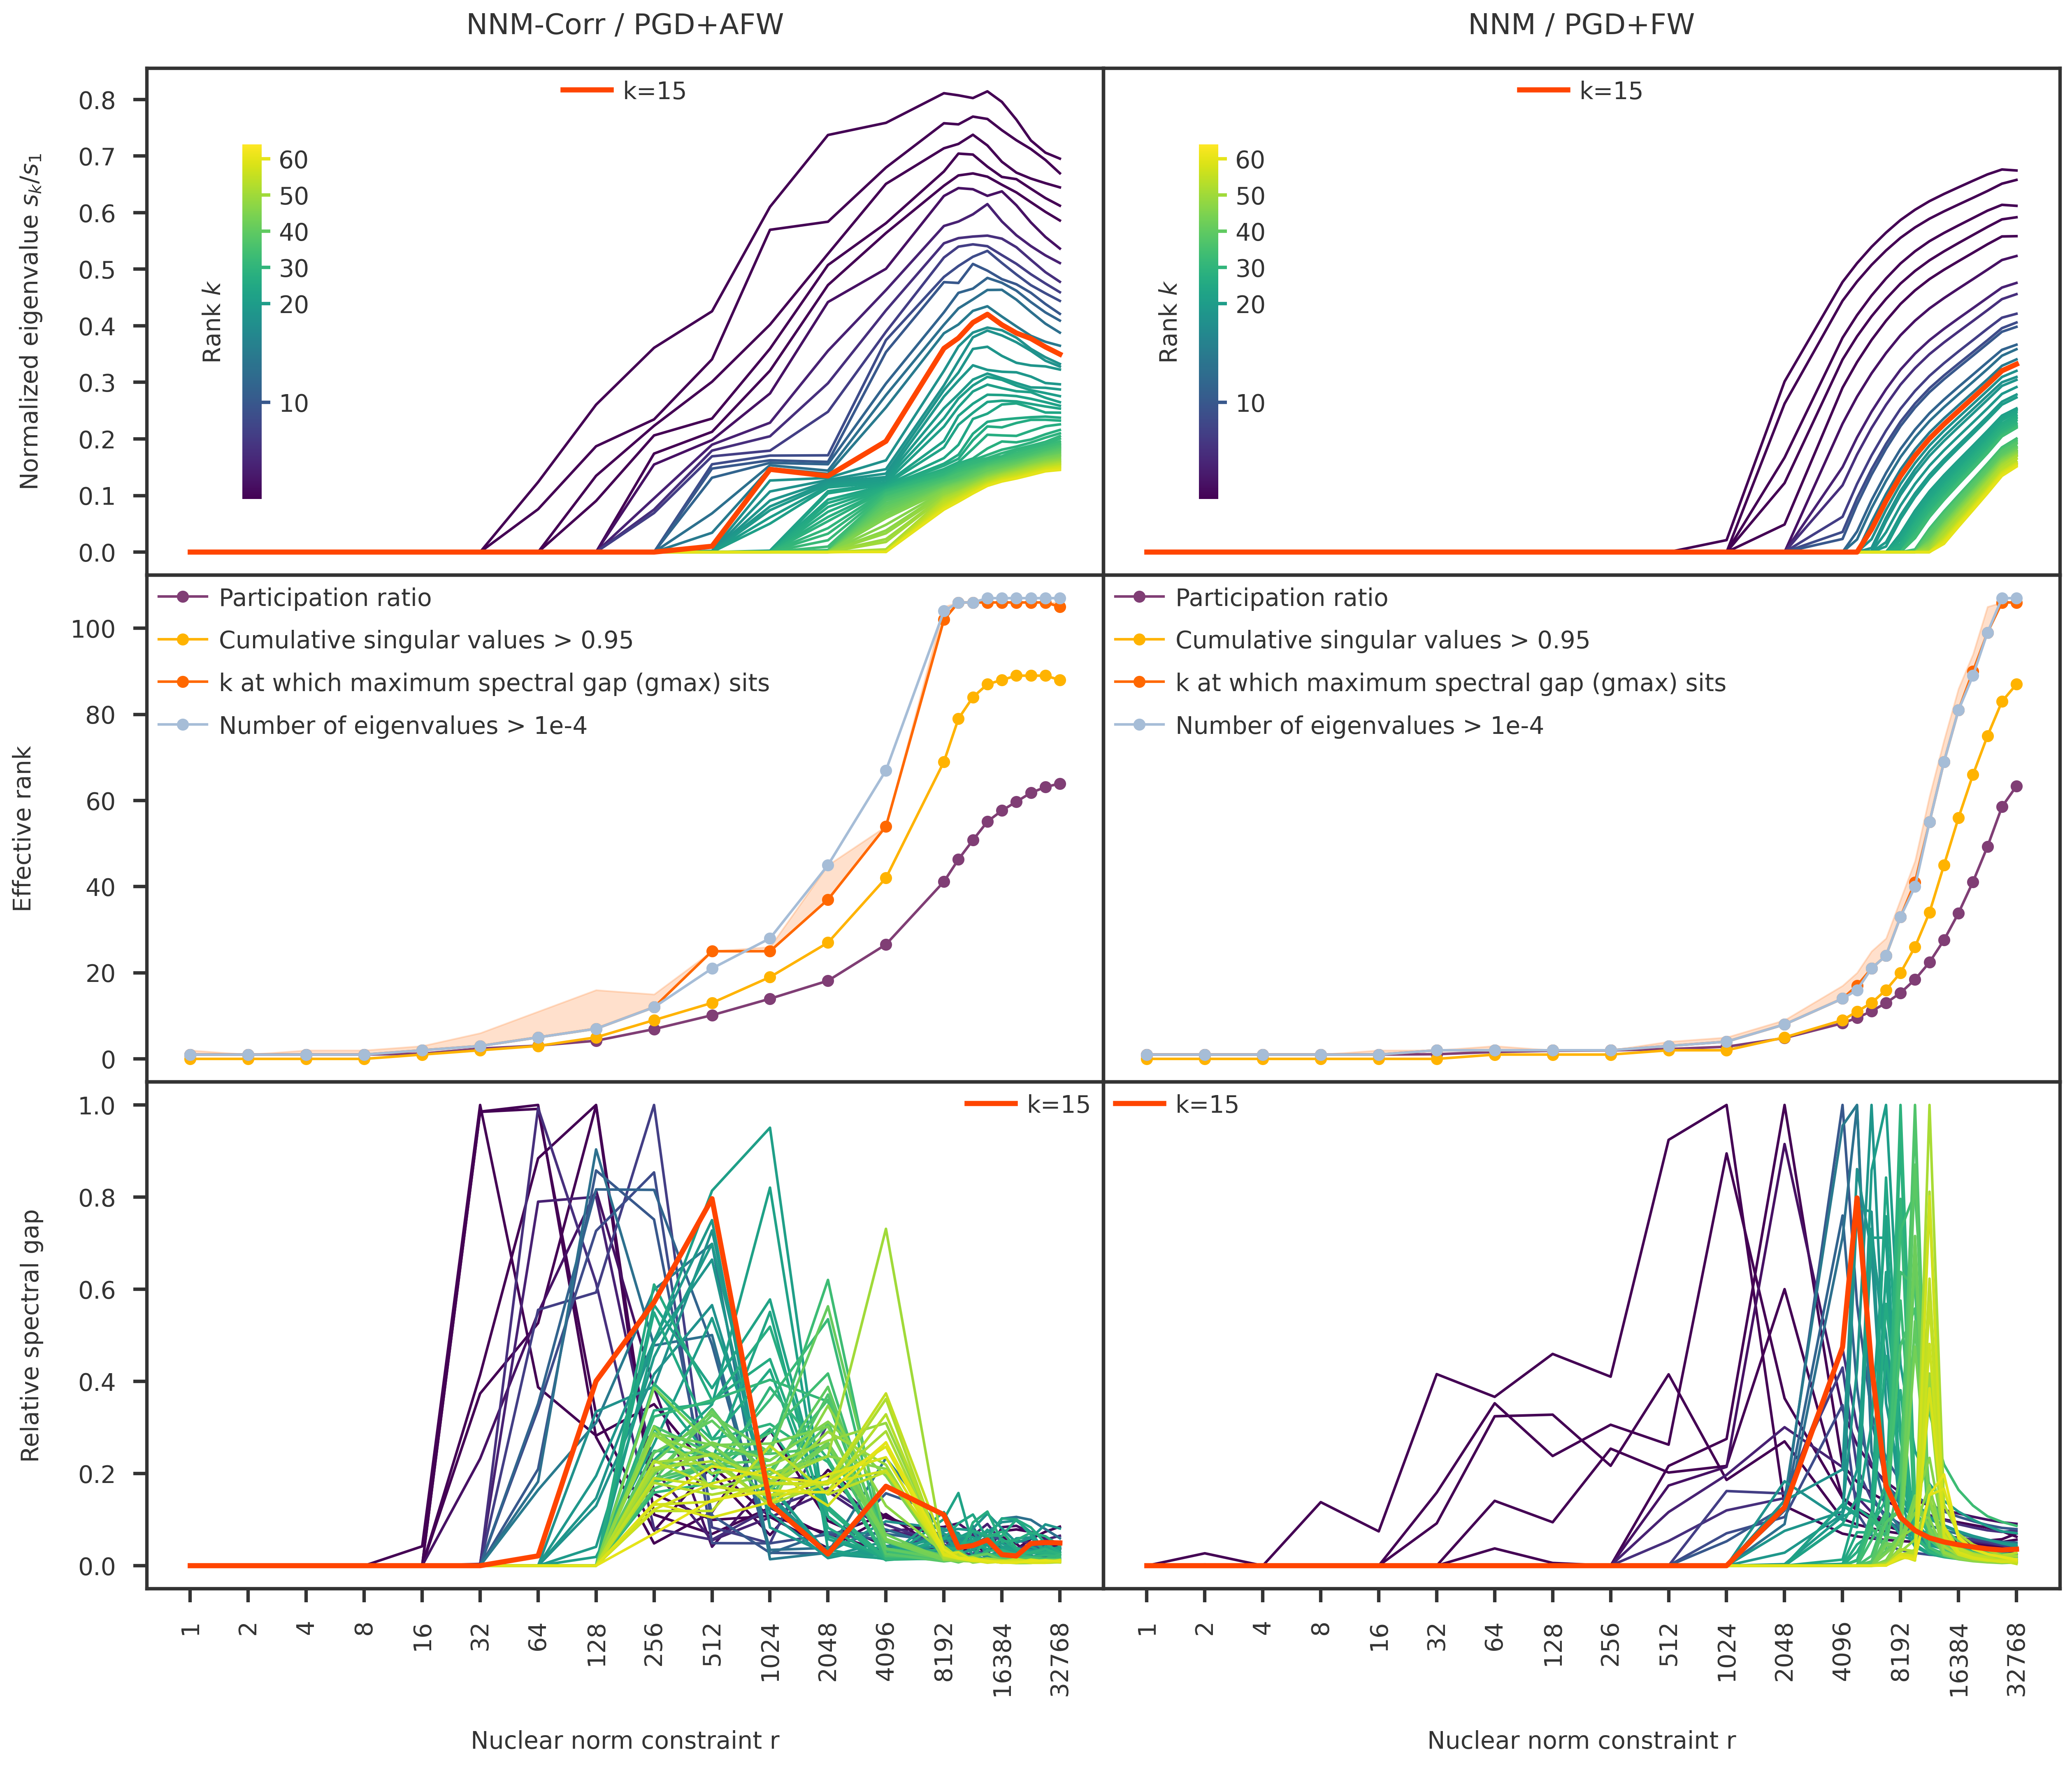

In [4]:
def get_r_scaled(x, scale="log2"):
    x = np.asarray(x, dtype=float)
    powers = np.arange(np.ceil(np.log2(x.min())), np.floor(np.log2(x.max())) + 1)
    xlabels = 2 ** powers
    
    if scale == "log10":
        xscale = np.log10(x)
        xticks = np.log10(xlabels)
    elif scale == "log2":
        xscale = np.log2(x)
        xticks = np.log2(xlabels)
    else:
        xscale = x
        xticks = xlabels

    xlabel_str = [f"{r:g}" for r in xlabels]
    return xscale, xticks, xlabel_str

def style_blank_axis(ax):
    ax.tick_params(bottom = False, top = False, left = False, right = False,
        labelbottom = False, labeltop = False, labelleft = False, labelright = False)
    

def style_colorbar_yticks(cbar, cmap, norm):
    for tick, value in zip(cbar.ax.yaxis.get_major_ticks(), cbar.ax.get_yticks()):
        color = cmap(norm(value))
        tick.tick1line.set_markeredgecolor(color)
        tick.tick2line.set_markeredgecolor(color)
        tick.tick1line.set_color("none")
        tick.tick2line.set_color("none")
    # for tick_label, value in zip(cbar.ax.get_yticklabels(), cbar.ax.get_yticks()):
        # tick_label.set_color(cmap(norm(value)))


def make_line_plots_with_colorbar_inset(ax, x, y, ycols,
        ylabel="", cbar_label="", cbar_xpos="", show_cbar=True,
        vcenter=None, cmap=None, norm=None):
    """
    Create K = len(ycols) line plots, color maps to values in ycols
    x : ndarray(N,)
    y : ndarray(N, K), columns of y correspond to values in k_list
    
    Returns cmap, norm for future use.
    """
    
    from matplotlib.cm import ScalarMappable

    if cmap is None:
        cmap = mpl_cmaps.get_cmap("viridis").copy()
    if norm is None:
        vmin = min(ycols)
        vmax = max(ycols)
        if vcenter is None: vcenter = (vmin + vmax) / 2.
        norm = mpl_colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    
    for i, k in enumerate(ycols):
        ax.plot(x, y[:, i], color=cmap(norm(i)))
        
    ax.set_ylabel(ylabel)

    if show_cbar:
        cax = ax.inset_axes([cbar_xpos, 0.15, 0.02, 0.7]) 
        sm = ScalarMappable(norm=norm, cmap=cmap)
        cbar = plt.colorbar(sm, cax=cax, fraction = 0.1)

        # Colorbar style
        style_blank_axis(cbar.ax)
        cbar.ax.tick_params(right=True, labelright=True, pad=5, width=2, length=5)
        cbar.set_label(cbar_label, labelpad = 10)
        cbar.ax.yaxis.set_label_position('left')
        style_colorbar_yticks(cbar, cmap, norm)
        for side, border in list(cbar.ax.spines.items()):
            border.set_visible(False)

    return cmap, norm
    
        
def make_singular_value_plots(ax1, ax2, ax3, prefix, 
        subspace_out_dir, r_scale='log10', show_yaxis=True, k_highlight=20):
    # load data 
    subspace_df = load_subspace_npz(subspace_out_dir, prefix)
    df          = get_subspace_spectrum(subspace_df, use_mean=True)    
    nucnorms    = df["nucnorm"].to_numpy(dtype=float)
    r_fits      = nucnorms * np.sqrt(0.5)
    
    # common x-axis for all plots
    x, xticks, xlabels  = get_r_scaled(nucnorms, scale=r_scale)
    ylabel=""
    
    # -- ax1: fan of normalized singular values --
    k_list = np.arange(4, 65)
    k_center = 15
    y = get_singular_value_metrics(df, k_list, metric="norm_value")
    show_cbar = True
    if show_yaxis: 
        # show_cbar = True
        ylabel=r"Normalized eigenvalue $s_k / s_1$"
    cmap, norm = make_line_plots_with_colorbar_inset(
        ax1, x, y, k_list,
        show_cbar=show_cbar,
        ylabel=ylabel, cbar_label=r"Rank $k$", cbar_xpos=0.1,
        vcenter=k_center)
    ax1.plot(x, y[:, k_highlight-1], color='orangered', lw=3, label=f"k={k_highlight:d}")
    ax1.legend(frameon = False, handlelength = 2, loc='upper center')
    
    # -- ax2: effective ranks --
    rank_methods = {
        "participation_ratio": 
            {"thres": None, "label": "Participation ratio"}, 
        "energy": 
            {"thres": 0.95, "label": f"Cumulative singular values > 0.95"}, 
        "spectral_gap": 
            {"thres": None, "label": "k at which maximum spectral gap (gmax) sits"},
        "count": 
            {"thres": 1e-4, "label": "Number of eigenvalues > 1e-4"},
        "spectral_gap_loose":
            {"thres": 0.7,  "label": "Max k at which spectral gap > 70% gmax"},
    }
    ranks = {}
    rank_lines = {}
    for m, mdict in rank_methods.items():
        ranks[m] = get_effective_ranks(df, nucnorms, method=m, thres=mdict["thres"])
        if m != "spectral_gap_loose":
            rank_lines[m], = ax2.plot(x, ranks[m],  'o-', label=mdict["label"])

    ax2.fill_between(x, ranks["spectral_gap"], ranks["spectral_gap_loose"], 
                     color=rank_lines["spectral_gap"].get_color(), alpha=0.2)

    if show_yaxis: 
        ylabel="Effective rank"
    ax2.legend(frameon = False, handlelength = 2)
    ax2.set_ylabel(ylabel)
    
    # -- ax3: relative spectral gap --
    # k_list = [8, 10, 12, 15, 20, 25, 30, 40]
    y = get_singular_value_metrics(df, k_list, metric="relative_gap")       
    for i, k in enumerate(k_list):
        # ax3.plot(x, y[:, i], 'o-', label=f"{k}")
        ax3.plot(x, y[:, i], color=cmap(norm(i)))
    ax3.plot(x, y[:, k_highlight-1], color='orangered', lw=3, label=f"k={k_highlight:d}")
    if show_yaxis:
        ylabel=r"Relative spectral gap"
    ax3.legend(frameon = False, handlelength = 2)
    ax3.set_ylabel(ylabel)

    
    # -- mark the x-axis --
    ax3.set_xticks(xticks)
    ax3.set_xticklabels(xlabels, rotation=90)
    ax3.set_xlabel("Nuclear norm constraint r")
    return


fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(nrows=3, ncols=2, wspace=0, hspace=0)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax5 = fig.add_subplot(gs[1, 1], sharey=ax2)
ax6 = fig.add_subplot(gs[2, 1], sharey=ax3)

for ax in (ax1, ax2, ax3, ax4, ax5, ax6):
    style_blank_axis(ax)
    ax.patch.set_alpha(0.0)
for ax in (ax1, ax2, ax3):
    ax.tick_params(left=True, labelleft=True)
for ax in (ax3, ax6):
    ax.tick_params(bottom=True, labelbottom=True)

prefix1 = "pgd_afw_nnm_corr"
make_singular_value_plots(
    ax1, ax2, ax3, 
    prefix1, subspace_out_dir, 
    r_scale='log2', k_highlight=15,
)
ax1.set_title("NNM-Corr / PGD+AFW", pad=20)

prefix2 = "pgd_fw_nnm"
make_singular_value_plots(
    ax4, ax5, ax6, 
    prefix2, subspace_out_dir, 
    r_scale='log2', show_yaxis=False, k_highlight=15,
)
ax4.set_title("NNM / PGD+FW", pad=20)

plt.savefig('figures/cvsr_singular_value_spectrum.pdf', bbox_inches='tight')
plt.show()

**Figure.** NNM-Corr resolves latent factors in rank order across a broad budget range — yielding a stable rank plateau — whereas NNM keeps all factors suppressed until they collapse in together at high r, with no stable regime.

**Top row — the eigenvalue fan.** The decisive difference is where the factors are born. NNM-Corr starts lifting factors off zero at r≈16–32 and admits them progressively with increasing r. NNM keeps everything pinned at zero until r≈2048–4096 and then dumps the entire spectrum in over a single octave — the curves all detach almost simultaneously in a near-vertical wall. So NNM has essentially no resolved ordering of factors: there's one budget regime where nothing exists and an adjacent one where everything exists at once. NNM-Corr resolves factors one trait at a time. That's the whitening doing exactly what it should: by deflating the correlated-noise eigenvalues, the true factors clear the noise floor at much lower budget and in rank order, instead of being buried until the budget is large enough to lift signal and inflated-noise together.

**Middle row — the rank proxies.** In NNM-Corr the ranks track each other smoothly and stay close through r≈256–2048. In NNM they are flat near zero, then all four shoot up together past r≈4096 with the count and energy measures racing to ~107 (full dimension) almost immediately. NNM never exhibits a regime where the rank measures separate from the ambient dimension in a controlled way — it goes from nothing to saturated. The orange gmax-location curve is the one to watch: in NNM-Corr it has a visible step-and-hold around k≈25 across r≈512–1024 before climbing again; in NNM it has no such shelf.

**Bottom row — the relative spectral gap.** NNM-Corr shows a broad band of high gap values spread across r≈256–4096 — many factors carry substantial relative gap over a wide budget range, the "broad peak." NNM shows gap structure that is either near-zero or collapsed into a narrow near-vertical thicket at r≈8192–16384 where everything transitions at once. NNM's gaps are concentrated at one budget; NNM-Corr's are distributed over an interval. This is the regularization-path signature of the wider detectability margin — supercritical (NNM-Corr) versus marginal/critical (NNM).


The gap in the plateau is broad and broad cuts both ways: it means robust, but it also means the exact k is a little soft — somewhere around 15—25, not pinned to one integer. The cleanest way to report it is "rank ≈ 15—25 stable across $r \in [256, 1024]$". Second, the band sits among the near-degenerate tangle in the bottom panel — are these meaningful? Check that s_15/s_1 is still an appreciable fraction (the top panel suggests the k≈15 curve is well above the 0.1 floor in this r range, which is reassuring).

## Claim
The gap-vs-r panel shows NNM-Corr does have a stable regime and NNM doesn't, and that difference is mechanistically attributable to the noise correction widening the BBP margin. This is a clean methods result: **correlated-noise whitening converts NNM's all-at-once collapse into an ordered factor-entry path with a rank plateau.**


Things to do:
1. Add the analytic detection edge under A so "supercritical vs marginal" is a derived statement, not just a visual. 
2. Refit on a finer grid inside [256,4096] — the current x-ticks are powers of two, so the plateau is resolved by maybe three points; a denser grid turns "looks flat" into "is flat."